<a href="https://colab.research.google.com/github/iammarkdelacruz/aimcapstone_identify_patterns_associated_wASD/blob/main/ASD_Capstone_Corrected_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASD capstone corrected evaluation

Standalone UCI analysis companion: grouped nested CV, repaired PDP and exploratory subgroup uncertainty. No Philippine data. Run cells in order on CPU. The original results are historical; this is not external validation. See the included README for methodology and limitations.

In [1]:
%pip install -q numpy==2.3.5 pandas==2.2.3 scikit-learn==1.8.0 matplotlib==3.10.8 joblib==1.5.3 xgboost==3.0.5 ucimlrepo==0.0.7


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 27.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.5 which is incompatible.


If installation requests a restart, restart the session and continue below. The analysis launches in a separate Python process. The next cell writes the complete script, so no additional file upload is required.

In [2]:
%%writefile asd_nested_analysis.py
"""UCI 419 internal re-evaluation. Run as a script; no prior notebook state required."""
import argparse, hashlib, itertools, json, platform, shutil, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
 f1_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay,
 RocCurveDisplay, PrecisionRecallDisplay)

SEED=42
ITEMS=[f'A{i}_Score' for i in range(1,11)]
CONTEXT=['age','gender','ethnicity','jaundice','autism','country_of_res','used_app_before','age_desc','relation']
SCENARIOS={'A_full_score_reference':ITEMS+CONTEXT+['result'],
 'B_screening_reconstruction':ITEMS+CONTEXT,'C_contextual_prediction':CONTEXT}
LIMITATIONS='''Internal re-evaluation of an already inspected dataset, not prospective or external validation.
No scenario is selected using evaluation scores. A is a target-derived reference; B reconstructs screening labels; C investigates contextual signal.
Pooled out-of-fold predictions come from different fitted models. Fold mean AUC is the primary ranking summary; pooled AUC is descriptive.
Wilson intervals assume independent Bernoulli outcomes and are approximate for cross-validation predictions with overlapping training sets. They do not include full model-fitting uncertainty. Small groups remain uncertain.
PDP/ICE describes fitted model responses, not causal effects; correlated inputs can make interventions unrealistic.
No Philippine participant data are loaded. No clinical diagnosis or population prevalence claims are supported.
'''

def write_json(path,obj):
 path.write_text(json.dumps(obj,indent=2,default=lambda x:x.item() if hasattr(x,'item') else str(x)))

def load_data(csv=None):
 if csv:
  d=pd.read_csv(csv)
  target=next((c for c in ['class','Class/ASD','Class/ASD Traits'] if c in d),None)
  if target is None: raise ValueError('CSV must contain the original UCI class or Class/ASD target, not Philippine survey data.')
  raw=d[target];X=d[ITEMS+CONTEXT+['result']].copy()
 else:
  from ucimlrepo import fetch_ucirepo
  data=fetch_ucirepo(id=419);X=data.data.features.copy();raw=data.data.targets.iloc[:,0]
 X=X.replace('?',np.nan).reset_index(drop=True)
 for c in ITEMS+['age','result']: X[c]=pd.to_numeric(X[c],errors='raise')
 y=raw.astype(str).str.strip().str.upper().map({'NO':0,'YES':1}).reset_index(drop=True)
 if y.isna().any() or y.nunique()!=2: raise ValueError('Expected both UCI YES/NO screening classes; no unknown labels are imputed.')
 if len(X)!=292: raise ValueError(f'Expected UCI 419 with 292 rows, found {len(X)}. Verify the source before changing this guard.')
 return X,y.astype(int)

def splits(X,y,groups,n,seed):
 out=list(StratifiedGroupKFold(n_splits=n,shuffle=True,random_state=seed).split(X,y,groups))
 for a,b in out:
  assert set(groups[a]).isdisjoint(groups[b]),'Profile overlap across split'
  if y.iloc[a].nunique()!=2 or y.iloc[b].nunique()!=2: raise ValueError('Fold lacks both classes; review splitting plan.')
 return out

def prep(X):
 num=X.select_dtypes(include=np.number).columns.tolist();cat=[c for c in X if c not in num]
 return ColumnTransformer([
  ('num',Pipeline([('impute',SimpleImputer(strategy='median',keep_empty_features=True)),('scale',StandardScaler())]),num),
  ('cat',Pipeline([('impute',SimpleImputer(strategy='constant',fill_value='Unknown',keep_empty_features=True)),('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cat)])

def grids(smoke=False):
 models=[(DummyClassifier(strategy='most_frequent'),{}),
  (LogisticRegression(class_weight='balanced',max_iter=5000,random_state=SEED),{'C':[.01,.1,1,10]}),
  (DecisionTreeClassifier(class_weight='balanced',random_state=SEED),{'max_depth':[3,5,None],'min_samples_leaf':[1,4]}),
  (RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=SEED,n_jobs=1),{'max_depth':[3,5,None],'min_samples_leaf':[1,4]}),
  (SVC(probability=True,class_weight='balanced',random_state=SEED),{'C':[.1,1,10],'gamma':['scale']})]
 if not smoke:
  from xgboost import XGBClassifier
  models.append((XGBClassifier(n_estimators=200,learning_rate=.05,eval_metric='logloss',random_state=SEED,n_jobs=1),{'max_depth':[2,3],'min_child_weight':[1,3]}))
 else: models=models[:2]
 return [{'model':[m],**{f'model__{k}':v[:1] if smoke else v for k,v in params.items()}} for m,params in models]

def fit_search(X,y,cv,jobs,smoke):
 search=GridSearchCV(Pipeline([('preprocess',prep(X)),('model',DummyClassifier())]),grids(smoke),cv=cv,scoring='roc_auc',n_jobs=jobs,refit=True,error_score='raise',return_train_score=False)
 return search.fit(X,y)

def prob(model,X):
 idx=list(model.classes_).index(1)
 return model.predict_proba(X)[:,idx]

def metrics(y,p):
 pred=(np.asarray(p)>=.5).astype(int);tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
 return dict(n=len(y),tn=int(tn),fp=int(fp),fn=int(fn),tp=int(tp),accuracy=accuracy_score(y,pred),precision=precision_score(y,pred,zero_division=0),recall=recall_score(y,pred,zero_division=0),specificity=tn/(tn+fp),fpr=fp/(tn+fp),fnr=fn/(fn+tp),f1=f1_score(y,pred,zero_division=0),roc_auc=roc_auc_score(y,p),average_precision=average_precision_score(y,p))

def wilson(k,n):
 if n==0:return (np.nan,np.nan,np.nan)
 z=1.959963984540054;p=k/n;den=1+z*z/n
 center=(p+z*z/(2*n))/den;half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
 return p,max(0,center-half),min(1,center+half)

def fairness(X,y,p,scenario):
 pred=(p>=.5).astype(int);rows=[]
 age=pd.cut(X.age,[-np.inf,5,8,12,np.inf],labels=['<=5','6-8','9-12','13+']).astype(object).fillna('Unknown')
 for attr,values in [('gender',X.gender.fillna('Unknown').astype(str)),('age_group',age)]:
  labels=list(dict.fromkeys((['<=5','6-8','9-12','13+','Unknown'] if attr=='age_group' else sorted(values.unique()))))
  for label in labels:
   mask=np.asarray(values==label);yt=y.to_numpy()[mask];yp=pred[mask]
   tn,fp,fn,tp=confusion_matrix(yt,yp,labels=[0,1]).ravel() if len(yt) else (0,0,0,0)
   for rate,k,n in [('recall',tp,tp+fn),('specificity',tn,tn+fp),('fpr',fp,tn+fp),('fnr',fn,tp+fn),('selection_rate',tp+fp,len(yt))]:
    est,lo,hi=wilson(k,n);rows.append(dict(scenario=scenario,attribute=attr,group=label,n_group=len(yt),n_positive=int(tp+fn),n_negative=int(tn+fp),metric=rate,events=int(k),denominator=int(n),estimate=est,ci95_lower=lo,ci95_upper=hi,method='Approximate Wilson; pooled OOF predictions'))
 return pd.DataFrame(rows)

def gaps(audit):
 rows=[]
 for (attr,metric),part in audit.groupby(['attribute','metric']):
  part=part[part.denominator>0]
  for (_,a),(_,b) in itertools.combinations(part.iterrows(),2):
   diff=a.estimate-b.estimate
   # Newcombe-style combination of Wilson limits, approximate for OOF dependence.
   lo=diff-np.sqrt((a.estimate-a.ci95_lower)**2+(b.ci95_upper-b.estimate)**2)
   hi=diff+np.sqrt((a.ci95_upper-a.estimate)**2+(b.estimate-b.ci95_lower)**2)
   rows.append(dict(attribute=attr,metric=metric,group_a=a.group,group_b=b.group,difference_a_minus_b=diff,ci95_lower=max(-1,lo),ci95_upper=min(1,hi),method='Approximate Newcombe-Wilson; no multiplicity correction; OOF dependence not included'))
 return pd.DataFrame(rows)

def save_fig(path):
 plt.tight_layout();plt.savefig(path,dpi=160,bbox_inches='tight');plt.close()

def pdp_ice(model,X,feature,grid,dest):
 predictions=[]
 for value in grid:
  changed=X.copy();changed[feature]=value;predictions.append(prob(model,changed))
 ice=np.asarray(predictions).T
 pd.DataFrame(ice,columns=[str(x) for x in grid]).to_csv(dest/f'ice_{feature}.csv',index_label='reference_row')
 pd.DataFrame({'feature_value':grid,'mean_positive_screen_probability':ice.mean(axis=0)}).to_csv(dest/f'pdp_{feature}.csv',index=False)
 plt.figure(figsize=(6,4))
 for row in ice[:30]:plt.plot(grid,row,color='gray',alpha=.15)
 plt.plot(grid,ice.mean(axis=0),'o-',color='navy',label='PDP mean')
 plt.xlabel(feature);plt.ylabel('Positive-screen probability');plt.ylim(0,1);plt.legend()
 plt.title('Descriptive final-refit PDP / ICE')
 if len(grid)==2:plt.xticks(grid)
 save_fig(dest/f'pdp_{feature}.png')
 return ice

def run(X,y,out,outer_n=5,inner_n=3,jobs=2,smoke=False):
 out=Path(out);out.mkdir(parents=True,exist_ok=False)
 (out/'LIMITATIONS.txt').write_text(LIMITATIONS)
 # Group by complete original feature profile, excluding the outcome. These are not participant IDs.
 normalized=X.astype('string').fillna('<MISSING>')
 groups=pd.factorize(pd.MultiIndex.from_frame(normalized))[0]
 snapshot=X.copy();snapshot['class']=y.map({0:'NO',1:'YES'});snapshot.to_csv(out/'uci419_snapshot.csv',index=False)
 digest=hashlib.sha256((out/'uci419_snapshot.csv').read_bytes()).hexdigest()
 config=dict(seed=SEED,outer_folds=outer_n,inner_folds=inner_n,threshold=.5,selection_metric='inner CV ROC-AUC',scenario_selection='None; distinct scientific questions',grouping='Full original feature profile, outcome excluded',rows=len(X),unique_profiles=len(np.unique(groups)),snapshot_sha256=digest,smoke_test=smoke,source='UCI 419; Fadi Thabtah 2017; DOI 10.24432/C5659W',scenarios=SCENARIOS,python=platform.python_version())
 write_json(out/'run_config.json',config)
 (out/'requirements_executed.txt').write_text(subprocess.check_output([sys.executable,'-m','pip','freeze'],text=True))
 outer=splits(X,y,groups,outer_n,SEED)
 assignment=np.zeros(len(y),dtype=int)
 for f,(_,te) in enumerate(outer,1):assignment[te]=f
 pd.DataFrame({'row_id':np.arange(len(y)),'profile_group':groups,'outer_fold':assignment}).to_csv(out/'outer_assignments.csv',index=False)
 allfold=[];allpooled=[]
 for name,cols in SCENARIOS.items():
  print('\nScenario:',name,flush=True);dest=out/name;dest.mkdir();Z=X[cols];oof=np.full(len(y),np.nan)
  for fold,(tr,te) in enumerate(outer,1):
   print(f'  Outer fold {fold}/{outer_n}: inner search',flush=True)
   inner=splits(Z.iloc[tr],y.iloc[tr],groups[tr],inner_n,SEED+fold)
   write_json(dest/f'fold_{fold}_splits.json',{'train_rows':tr.tolist(),'test_rows':te.tolist(),'inner_splits':[{'train_rows':tr[a].tolist(),'validation_rows':tr[b].tolist()} for a,b in inner]})
   search=fit_search(Z.iloc[tr],y.iloc[tr],inner,jobs,smoke)
   pd.DataFrame(search.cv_results_).to_csv(dest/f'fold_{fold}_inner_search.csv',index=False)
   model=search.best_estimator_;oof[te]=prob(model,Z.iloc[te]);joblib.dump(model,dest/f'fold_{fold}_model.joblib')
   result=dict(scenario=name,fold=fold,selected_family=type(model.named_steps['model']).__name__,inner_best_auc=search.best_score_,**metrics(y.iloc[te],oof[te]))
   allfold.append(result);write_json(dest/f'fold_{fold}_selection.json',search.best_params_)
  assert np.isfinite(oof).all()
  pd.DataFrame({'row_id':np.arange(len(y)),'outer_fold':assignment,'y_true':y,'positive_probability':oof,'predicted_label':(oof>=.5).astype(int)}).to_csv(dest/'oof_predictions.csv',index=False)
  allpooled.append(dict(scenario=name,**metrics(y,oof)))
  for suffix,display in [('confusion_matrix',ConfusionMatrixDisplay),('roc',RocCurveDisplay),('precision_recall',PrecisionRecallDisplay)]:
   if suffix=='confusion_matrix':display.from_predictions(y,(oof>=.5).astype(int),labels=[0,1],display_labels=['Screen negative','Screen positive'])
   else:display.from_predictions(y,oof)
   plt.title(name+'\nNested out-of-fold '+suffix.replace('_',' '));save_fig(dest/f'{suffix}.png')
  audit=fairness(X,y,oof,name);audit.to_csv(dest/'subgroup_rates_ci.csv',index=False);gaps(audit).to_csv(dest/'subgroup_pairwise_gaps_ci.csv',index=False)
  # Separate final full-data refit for reuse/explanation; NEVER score it on training data as validation.
  print('  Final full-data CV selection and refit (not evaluation)',flush=True)
  final=fit_search(Z,y,splits(Z,y,groups,inner_n,SEED+100),jobs,smoke)
  joblib.dump(final.best_estimator_,dest/'final_refit_model.joblib');write_json(dest/'final_refit_config.json',{'params':final.best_params_,'purpose':'Full-data refit for descriptive explanations and reuse; no independent performance claim'})
  pd.DataFrame(final.cv_results_).to_csv(dest/'final_refit_search.csv',index=False)
  if name.startswith('B_'):
   for feature in ['A4_Score','A10_Score']:pdp_ice(final.best_estimator_,Z,feature,[0,1],dest)
  if name.startswith('C_'):pdp_ice(final.best_estimator_,Z,'age',sorted(Z.age.dropna().unique()),dest)
  pd.DataFrame(allfold).to_csv(out/'nested_fold_metrics.csv',index=False)
  pd.DataFrame(allpooled).to_csv(out/'pooled_oof_metrics.csv',index=False)
 folds=pd.DataFrame(allfold)
 folds.groupby('scenario')[['accuracy','recall','specificity','f1','roc_auc','average_precision']].agg(['mean','std']).to_csv(out/'nested_fold_summary.csv')
 (out/'COMPLETE.txt').write_text('All planned analyses completed. Read LIMITATIONS.txt before interpreting results. Fold SD is variability, not a confidence interval.\n')
 shutil.make_archive(str(out),'zip',out)
 print('\nFinished. Download:',str(out)+'.zip',flush=True)
 return out

if __name__=='__main__':
 parser=argparse.ArgumentParser();parser.add_argument('--csv');parser.add_argument('--output',default='asd_corrected_results');parser.add_argument('--jobs',type=int,default=2)
 args=parser.parse_args();X,y=load_data(args.csv);run(X,y,args.output,jobs=args.jobs)


Overwriting asd_nested_analysis.py


In [3]:
from datetime import datetime, timezone
from pathlib import Path
import subprocess, sys

OUTPUT_ROOT = Path('/content')  # Optionally change to a mounted Google Drive folder.
RESULT_DIR = OUTPUT_ROOT / ('asd_corrected_' + datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S'))

try:
    # Added capture_output=True and text=True to capture stderr as a string
    # Corrected the path to the script to reference it from the current working directory.
    script_path = Path.cwd() / 'asd_nested_analysis.py'
    result = subprocess.run([sys.executable, str(script_path), '--output', str(RESULT_DIR), '--jobs', '2'], check=True, capture_output=True, text=True)
    print("Script completed successfully.")
    print("Stdout:")
    print(result.stdout)
    if result.stderr:
        print("Stderr (if any):")
        print(result.stderr)
except subprocess.CalledProcessError as e:
    print(f"Error executing script: {e}")
    print("Stdout:")
    print(e.stdout)
    print("Stderr:")
    print(e.stderr)
    raise # Re-raise the exception after printing details for the user

Script completed successfully.
Stdout:

Scenario: A_full_score_reference
  Outer fold 1/5: inner search
  Outer fold 2/5: inner search
  Outer fold 3/5: inner search
  Outer fold 4/5: inner search
  Outer fold 5/5: inner search
  Final full-data CV selection and refit (not evaluation)

Scenario: B_screening_reconstruction
  Outer fold 1/5: inner search
  Outer fold 2/5: inner search
  Outer fold 3/5: inner search
  Outer fold 4/5: inner search
  Outer fold 5/5: inner search
  Final full-data CV selection and refit (not evaluation)

Scenario: C_contextual_prediction
  Outer fold 1/5: inner search
  Outer fold 2/5: inner search
  Outer fold 3/5: inner search
  Outer fold 4/5: inner search
  Outer fold 5/5: inner search
  Final full-data CV selection and refit (not evaluation)

Finished. Download: /content/asd_corrected_20260923_174637.zip



accuracy              recall            \
                                mean       std      mean       std   
scenario                                                             
A_full_score_reference      0.996552  0.007711  1.000000  0.000000   
B_screening_reconstruction  1.000000  0.000000  1.000000  0.000000   
C_contextual_prediction     0.503682  0.053734  0.525123  0.087041   

                           specificity                  f1            \
                                  mean       std      mean       std   
scenario                                                               
A_full_score_reference        0.993333  0.014907  0.996491  0.007846   
B_screening_reconstruction    1.000000  0.000000  1.000000  0.000000   
C_contextual_prediction       0.483871  0.043085  0.503820  0.064784   

                             roc_auc          average_precision                
                                mean      std              mean           std  
scenario                                                                       
A_full_score_reference      1.000000  0.00000          1.000000  5.551115e-17  
B_screening_reconstruction  1.000000  0.00000          1.000000  5.551115e-17  
C_contextual_prediction     0.548361  0.08462          0.580665  6.044477e-02

,scenario,n,tn,fp,fn,tp,accuracy,precision,recall,specificity,fpr,fnr,f1,roc_auc,average_precision
0,A_full_score_reference,292,150,1,0,141,0.996575,0.992958,1.000000,0.993377,0.006623,0.000000,0.996466,1.000000,1.00000
1,B_screening_reconstruction,292,151,0,0,141,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000
2,C_contextual_prediction,292,73,78,67,74,0.503425,0.486842,0.524823,0.483444,0.516556,0.475177,0.505119,0.518764,0.51526


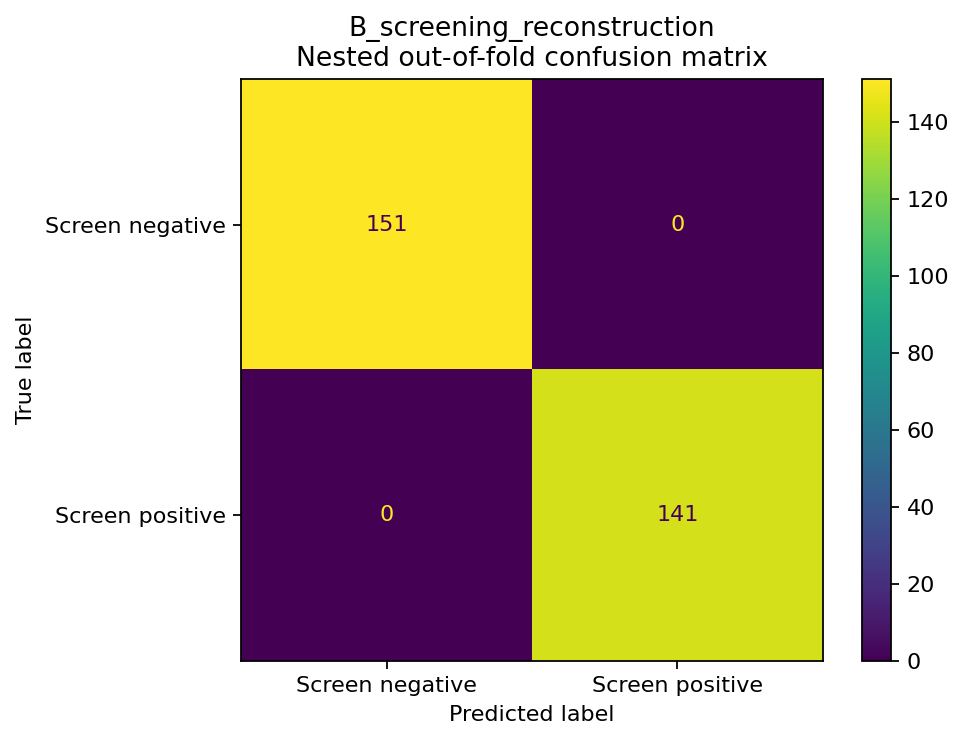

,scenario,attribute,group,n_group,n_positive,n_negative,metric,events,denominator,estimate,ci95_lower,ci95_upper,method
0,B_screening_reconstruction,gender,f,84,38,46,recall,38,38,1.000000,9.081901e-01,1.000000,Approximate Wilson; pooled OOF predictions
1,B_screening_reconstruction,gender,f,84,38,46,specificity,46,46,1.000000,9.229264e-01,1.000000,Approximate Wilson; pooled OOF predictions
2,B_screening_reconstruction,gender,f,84,38,46,fpr,0,46,0.000000,0.000000e+00,0.077074,Approximate Wilson; pooled OOF predictions
3,B_screening_reconstruction,gender,f,84,38,46,fnr,0,38,0.000000,0.000000e+00,0.091810,Approximate Wilson; pooled OOF predictions
4,B_screening_reconstruction,gender,f,84,38,46,selection_rate,38,84,0.452381,3.503572e-01,0.558570,Approximate Wilson; pooled OOF predictions
5,B_screening_reconstruction,gender,m,208,103,105,recall,103,103,1.000000,9.640452e-01,1.000000,Approximate Wilson; pooled OOF predictions
6,B_screening_reconstruction,gender,m,208,103,105,specificity,105,105,1.000000,9.647059e-01,1.000000,Approximate Wilson; pooled OOF predictions
7,B_screening_reconstruction,gender,m,208,103,105,fpr,0,105,0.000000,0.000000e+00,0.035294,Approximate Wilson; pooled OOF predictions
8,B_screening_reconstruction,gender,m,208,103,105,fnr,0,103,0.000000,0.000000e+00,0.035955,Approximate Wilson; pooled OOF predictions
9,B_screening_reconstruction,gender,m,208,103,105,selection_rate,103,208,0.495192,4.279519e-01,0.562607,Approximate Wilson; pooled OOF predictions


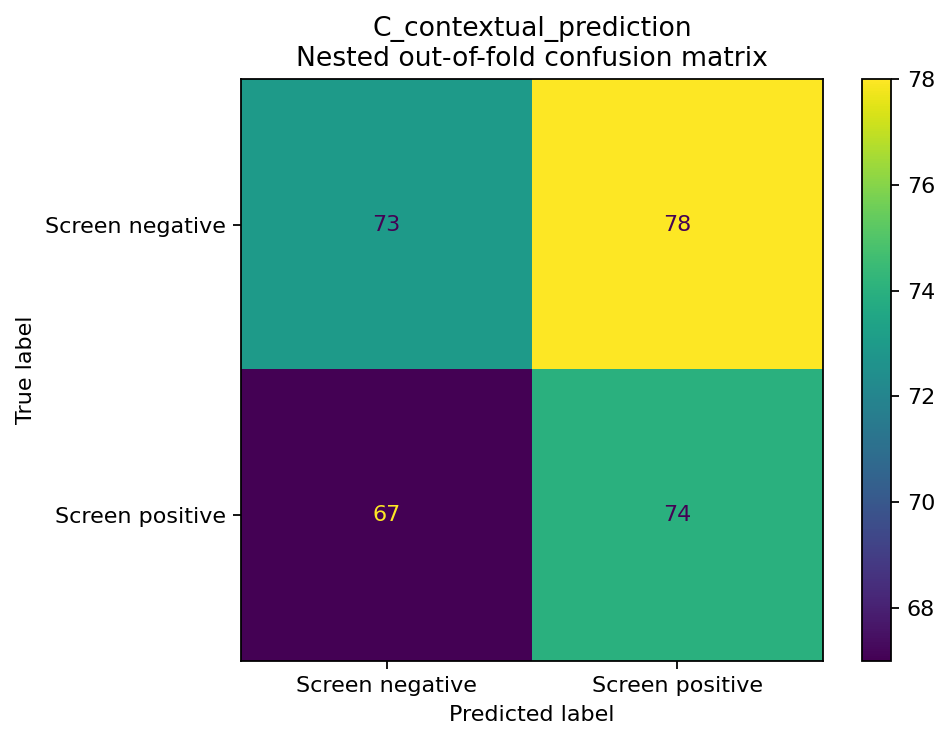

,scenario,attribute,group,n_group,n_positive,n_negative,metric,events,denominator,estimate,ci95_lower,ci95_upper,method
0,C_contextual_prediction,gender,f,84,38,46,recall,16,38,0.421053,0.278525,0.578077,Approximate Wilson; pooled OOF predictions
1,C_contextual_prediction,gender,f,84,38,46,specificity,28,46,0.608696,0.464568,0.736068,Approximate Wilson; pooled OOF predictions
2,C_contextual_prediction,gender,f,84,38,46,fpr,18,46,0.391304,0.263932,0.535432,Approximate Wilson; pooled OOF predictions
3,C_contextual_prediction,gender,f,84,38,46,fnr,22,38,0.578947,0.421923,0.721475,Approximate Wilson; pooled OOF predictions
4,C_contextual_prediction,gender,f,84,38,46,selection_rate,34,84,0.404762,0.306196,0.511658,Approximate Wilson; pooled OOF predictions
5,C_contextual_prediction,gender,m,208,103,105,recall,58,103,0.563107,0.466760,0.654916,Approximate Wilson; pooled OOF predictions
6,C_contextual_prediction,gender,m,208,103,105,specificity,45,105,0.428571,0.338088,0.524097,Approximate Wilson; pooled OOF predictions
7,C_contextual_prediction,gender,m,208,103,105,fpr,60,105,0.571429,0.475903,0.661912,Approximate Wilson; pooled OOF predictions
8,C_contextual_prediction,gender,m,208,103,105,fnr,45,103,0.436893,0.345084,0.533240,Approximate Wilson; pooled OOF predictions
9,C_contextual_prediction,gender,m,208,103,105,selection_rate,118,208,0.567308,0.499358,0.632816,Approximate Wilson; pooled OOF predictions


Internal re-evaluation of an already inspected dataset, not prospective or external validation.
No scenario is selected using evaluation scores. A is a target-derived reference; B reconstructs screening labels; C investigates contextual signal.
Pooled out-of-fold predictions come from different fitted models. Fold mean AUC is the primary ranking summary; pooled AUC is descriptive.
Wilson intervals assume independent Bernoulli outcomes and are approximate for cross-validation predictions with overlapping training sets. They do not include full model-fitting uncertainty. Small groups remain uncertain.
PDP/ICE describes fitted model responses, not causal effects; correlated inputs can make interventions unrealistic.
No Philippine participant data are loaded. No clinical diagnosis or population prevalence claims are supported.



In [4]:
import pandas as pd
from IPython.display import display, Image
assert (RESULT_DIR / 'COMPLETE.txt').exists(), 'Run incomplete; inspect the error above.'
display(pd.read_csv(RESULT_DIR / 'nested_fold_summary.csv', header=[0,1], index_col=0))
display(pd.read_csv(RESULT_DIR / 'pooled_oof_metrics.csv'))
for scenario in ['B_screening_reconstruction', 'C_contextual_prediction']:
    display(Image(filename=str(RESULT_DIR / scenario / 'confusion_matrix.png')))
    display(pd.read_csv(RESULT_DIR / scenario / 'subgroup_rates_ci.csv'))
print((RESULT_DIR / 'LIMITATIONS.txt').read_text())


In [6]:
from google.colab import files
files.download(str(RESULT_DIR) + '.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>